## **Customer Purchase Prediction** <br>
Business Problem: Tidak semua visitor pada situs e-commerce melakukan pembelian, sehingga sulit untuk mengidentifikasi visitor yang berpotensi melakukan pembelian serta memahami faktor yang memengaruhi keputusan pembelian.

Tujuan: Mengetahui apakah seorang pengunjung website berpotensi melakukan pembelian berdasarkan perilaku mereka selama mengunjungi website.


Target: Revenue <br>
1. True = melakukan pembelian
2. False = tidak melakukan pembelian

#### Dataset <br>
Kolom Numerik

* `Administrative` : Jumlah halaman administratif yang dikunjungi.
* `Administrative_Duration` : Durasi waktu yang dihabiskan pada halaman administratif.
* `Informational` : Jumlah halaman informasi yang dikunjungi.
* `Informational_Duration` : Durasi waktu yang dihabiskan pada halaman informasi.
* `ProductRelated` : Jumlah halaman terkait produk yang dikunjungi.
* `ProductRelated_Duration` : Durasi waktu yang dihabiskan pada halaman terkait produk.
* `BounceRates` : Persentase kunjungan yang berakhir setelah hanya mengakses satu halaman.
* `ExitRates` : Persentase kunjungan yang berakhir pada halaman tertentu.
* `PageValues` : Nilai rata-rata halaman yang dikunjungi sebelum transaksi atau konversi.
* `SpecialDay` : Tingkat kedekatan waktu kunjungan dengan hari khusus.
* `OperatingSystems` : Kode sistem operasi yang digunakan visitor.
* `Browser` : Kode browser yang digunakan visitor.
* `Region` : Kode wilayah visitor.
* `TrafficType` : Kode jenis sumber traffic visitor.

Kolom Kategorikal

* `Month` : Bulan saat visitor mengunjungi website.
* `VisitorType` : Jenis visitor, seperti visitor baru atau visitor yang kembali.

Kolom Boolean

* `Weekend` : Menunjukkan apakah kunjungan terjadi pada akhir pekan.
* `Revenue` : Menunjukkan apakah visitor melakukan pembelian.




In [1]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d henrysue/online-shoppers-intention

Dataset URL: https://www.kaggle.com/datasets/henrysue/online-shoppers-intention
License(s): other
online-shoppers-intention.zip: Skipping, found more recently modified local copy (use --force to force download)


In [4]:
import zipfile

with zipfile.ZipFile("online-shoppers-intention.zip", "r") as zip_ref:
    zip_ref.extractall("/content/dataset")

#### Data Understanding

In [5]:
import pandas as pd

df = pd.read_csv("/content/dataset/online_shoppers_intention.csv")

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [6]:
df.shape

(12330, 18)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [8]:
print("Kolom numerik:", df.select_dtypes(include='number').columns.tolist())
print("Kolom kategorikal:", df.select_dtypes(include=['object', 'string']).columns.tolist())
print("Kolom boolean:", df.select_dtypes(include=['bool']).columns.tolist())

Kolom numerik: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']
Kolom kategorikal: ['Month', 'VisitorType']
Kolom boolean: ['Weekend', 'Revenue']


In [9]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [10]:
# Cek nilai unik untuk kolom kategorikal & boolean
print("Month:", df['Month'].unique())
print("\nVisitorType:", df['VisitorType'].unique())
print("\nWeekend:", df['Weekend'].unique())
print("\nRevenue:", df['Revenue'].unique())

Month: ['Feb' 'Mar' 'May' 'Oct' 'June' 'Jul' 'Aug' 'Nov' 'Sep' 'Dec']

VisitorType: ['Returning_Visitor' 'New_Visitor' 'Other']

Weekend: [False  True]

Revenue: [False  True]


In [11]:
df.isnull().sum()

,0
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


In [12]:
df.duplicated().sum()

np.int64(125)

#### Exploratory Data Analysis (Raw)

In [13]:
# Target distribution (Revenue)
# Jumlah masing-masing kelas
df['Revenue'].value_counts()

,count
Revenue,
False,10422
True,1908


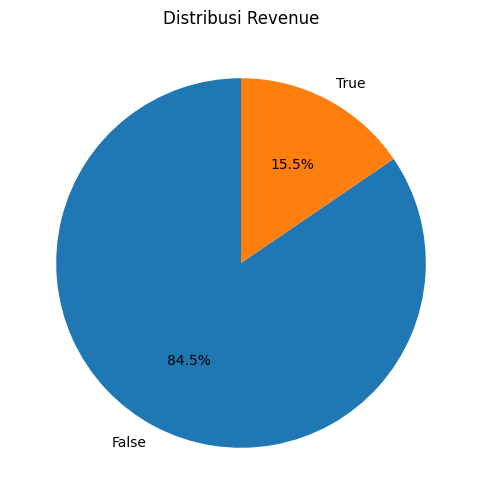

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

revenue_counts = df['Revenue'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    revenue_counts,
    labels=revenue_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribusi Revenue')
plt.show()

In [15]:
# Mean tiap fitur numerik per grup Revenue
# Membandingkan rata-rata perilaku visitor yang membeli (True) dengan tidak membeli (False)
df.groupby('Revenue').mean(numeric_only=True)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Weekend
Revenue,,,,,,,,,,,,,,,
False,2.117732,73.740111,0.451833,30.236237,28.714642,1069.987809,0.025317,0.047378,1.975998,0.068432,2.129726,2.339474,3.159278,4.078392,0.227308
True,3.393606,119.483244,0.786164,57.611427,48.210168,1876.209615,0.005117,0.019555,27.264518,0.023166,2.092767,2.453354,3.082285,4.021488,0.261530


Visitor yang melakukan pembelian memiliki rata-rata jumlah halaman yang dikunjungi dan durasi kunjungan yang lebih tinggi pada kategori administratif, informasi, dan produk dibandingkan visitor yang tidak melakukan pembelian.

In [16]:
num_cols = ['Administrative','Administrative_Duration','Informational','Informational_Duration',
            'ProductRelated','ProductRelated_Duration','BounceRates','ExitRates','PageValues','SpecialDay']

In [17]:
# Korelasi setiap variabel numerik terhadap Revenue
corr_target = df[num_cols].copy()
corr_target['Revenue'] = df['Revenue'].astype(int)

corr_target.corr()['Revenue'].sort_values(ascending=False)

,Revenue
Revenue,1.000000
PageValues,0.492569
ProductRelated,0.158538
ProductRelated_Duration,0.152373
Administrative,0.138917
Informational,0.095200
Administrative_Duration,0.093587
Informational_Duration,0.070345
SpecialDay,-0.082305
BounceRates,-0.150673


PageValues memiliki korelasi positif paling kuat dengan Revenue sebesar 0,493. Sementara itu, ExitRates memiliki korelasi negatif paling kuat sebesar -0,207. Variabel ProductRelated dan ProductRelated_Duration juga menunjukkan hubungan positif, tetapi relatif lemah.

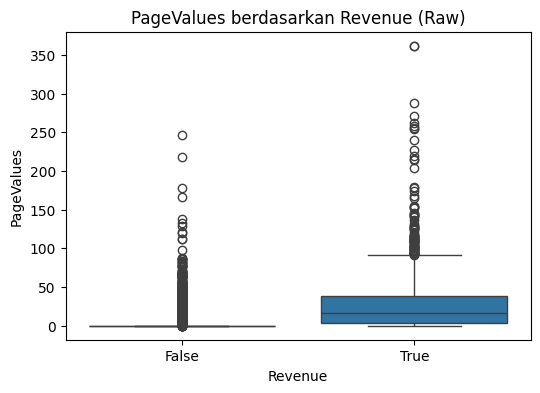

In [18]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Revenue', y='PageValues')
plt.title('PageValues berdasarkan Revenue (Raw)')
plt.show()

Visitor yang melakukan pembelian cenderung memiliki PageValues yang lebih tinggi dibandingkan visitor yang tidak melakukan pembelian.

In [19]:
# Conversion rate per VisitorType
# Membandingkan conversion rate berdasarkan tipe visitor
visitor_conv = df.groupby('VisitorType')['Revenue'].agg(['mean','count'])
visitor_conv

,mean,count
VisitorType,,
New_Visitor,0.249115,1694
Other,0.188235,85
Returning_Visitor,0.139323,10551


Returning Visitor merupakan tipe visitor dengan jumlah terbanyak, yaitu 10.551 visitor. Namun, New Visitor memiliki conversion rate tertinggi sebesar 24,91%, sedangkan Returning Visitor memiliki conversion rate sebesar 13,93%. Hal ini menunjukkan bahwa meskipun Returning Visitor lebih dominan dalam jumlah kunjungan dan proporsi pembelian pada New Visitor lebih tinggi.

In [20]:
# Conversion rate per Weekend
# Membandingkan tingkat pembelian berdasarkan hari weekend
weekend_conv = df.groupby('Weekend')['Revenue'].agg(['mean','count'])
weekend_conv

,mean,count
Weekend,,
False,0.148911,9462
True,0.173989,2868


Sebagian besar visitor mengunjungi website bukan weekend, yaitu 9.462 visitor, sedangkan kunjungan pada weekend berjumlah 2.868 visitor. Meskipun jumlah visitor pada weekend lebih sedikit, proporsi visitor yang melakukan pembelian sedikit lebih tinggi dibandingkan bukan weekend.

In [21]:
# Conversion rate per Bulan
month_conv = df.groupby('Month')['Revenue'].agg(['mean', 'count'])
month_conv

,mean,count
Month,,
Aug,0.175520,433
Dec,0.125072,1727
Feb,0.016304,184
Jul,0.152778,432
June,0.100694,288
Mar,0.100682,1907
May,0.108502,3364
Nov,0.253502,2998
Oct,0.209472,549


Persentase visitor yang melakukan pembelian berbeda pada setiap bulan. November memiliki persentase pembelian tertinggi sebesar 25,35% dengan 2.998 visitor, sedangkan Februari memiliki persentase terendah sebesar 1,63% dengan 184 visitor. Sementara itu, Mei memiliki jumlah visitor terbanyak, yaitu 3.364 visitor, tetapi hanya 10,85% yang melakukan pembelian.

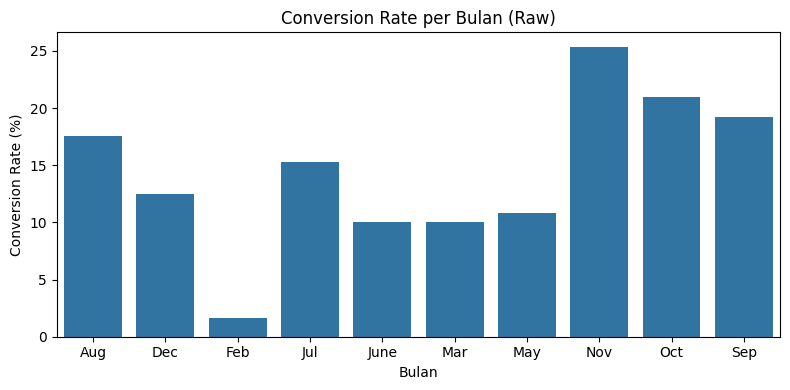

In [22]:
plt.figure(figsize=(8,4))
sns.barplot(x=month_conv.index, y=month_conv['mean']*100)
plt.title('Conversion Rate per Bulan (Raw)')
plt.ylabel('Conversion Rate (%)')
plt.xlabel('Bulan')
plt.tight_layout()
plt.show()

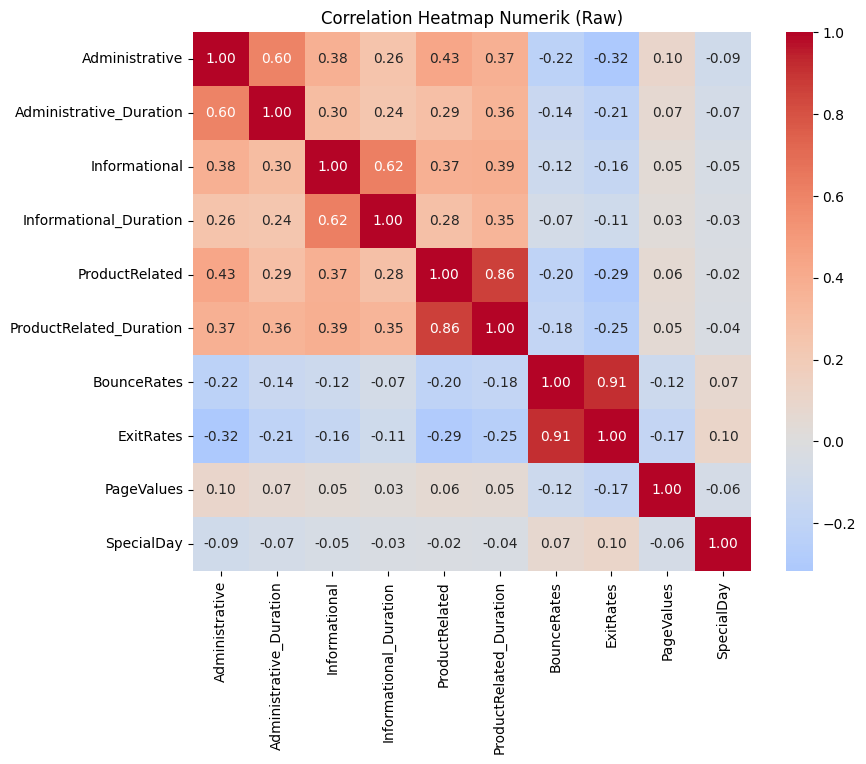

In [23]:
plt.figure(figsize=(9,7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap Numerik (Raw)')
plt.show()

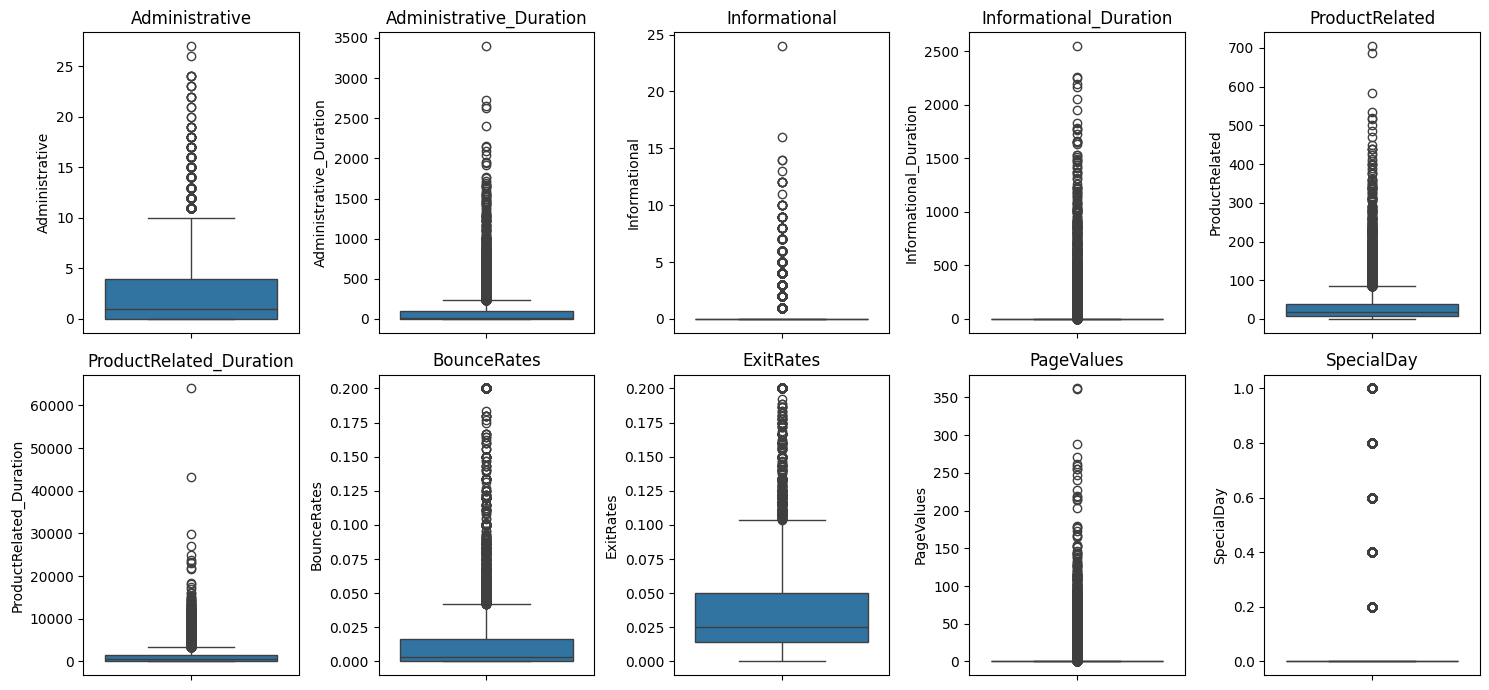

In [24]:
fig, axes = plt.subplots(2, 5, figsize=(15, 7))

for ax, col in zip(axes.flat, num_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

In [25]:
# Cek outlier ekstrem di fitur duration (Percentile check)
for col in ['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration']:
    print(f"{col}: max: {df[col].max():.1f} | p99: {df[col].quantile(0.99):.1f} "
          f"| p95: {df[col].quantile(0.95):.1f}")

Administrative_Duration: max: 3398.8 | p99: 830.6 | p95: 348.3
Informational_Duration: max: 2549.4 | p99: 716.4 | p95: 195.0
ProductRelated_Duration: max: 63973.5 | p99: 8701.1 | p95: 4300.3


Ketiga fitur durasi (Administrative_Duration, Informational_Duration, ProductRelated_Duration) menunjukkan pola right-skewed dengan outlier ekstrem, terlihat dari selisih besar antara nilai maksimum dengan persentil ke-99 dan ke-95.

Pada Administrative_Duration, nilai maksimum mencapai 3398,8 detik, jauh di atas p99 (830,6 detik) dan p95 (348,3 detik). Pola serupa terlihat pada Informational_Duration, dengan nilai maksimum 2549,4 detik dibandingkan p99 sebesar 716,4 detik.

Outlier paling ekstrem ditemukan pada ProductRelated_Duration, di mana nilai maksimum mencapai 63.973,5 detik (17,8 jam), sementara 99% visitor lainnya memiliki durasi di bawah 8.701,1 detik (2,4 jam). Kesenjangan ini mengindikasikan adanya sesi anomali, kemungkinan tab yang dibiarkan terbuka tanpa aktivitas, bukan perilaku belanja yang wajar.

Alasan memakai presentil check: karena data durasi (Administrative_Duration, dll) sifatnya skewed (miring, ekor panjang ke kanan), bukan simetris. Kalau pakai IQR di data yang skewed, banyak nilai wajar bisa salah ke-flag jadi outlier. Percentile check (bandingin max vs p99 vs p95) lebih pas karena cuma buat lihat dulu seberapa jauh nilai ekstrem menyimpang, baru manual tentuin titik potong (capping) yang masuk akal, bukan rumus otomatis yang kaku kayak IQR.

#### Data Cleaning

In [26]:
df_clean = df.copy()

In [27]:
# Menghapus data duplikat
df_clean = df_clean.drop_duplicates()

In [28]:
# Convert boolean ke int
df_clean['Revenue'] = df_clean['Revenue'].astype(int)
df_clean['Weekend'] = df_clean['Weekend'].astype(int)

df_clean.dtypes

,0
Administrative,int64
Administrative_Duration,float64
Informational,int64
Informational_Duration,float64
ProductRelated,int64
ProductRelated_Duration,float64
BounceRates,float64
ExitRates,float64
PageValues,float64
SpecialDay,float64


In [29]:
df_clean.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,0,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,0,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,0,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,0,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,1,0


#### EDA (Clean Data)

In [30]:
df_clean.duplicated().sum()

np.int64(0)

In [31]:
# Statistik deskriptif setelah cleaning
df_clean[num_cols].describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay
count,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000
mean,2.338878,81.646331,0.508726,34.825454,32.045637,1206.982457,0.020370,0.041466,5.949574,0.061942
std,3.330436,177.491845,1.275617,141.424807,44.593649,1919.601400,0.045255,0.046163,18.653671,0.199666
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,8.000000,193.000000,0.000000,0.014231,0.000000,0.000000
50%,1.000000,9.000000,0.000000,0.000000,18.000000,608.942857,0.002899,0.025000,0.000000,0.000000
75%,4.000000,94.700000,0.000000,0.000000,38.000000,1477.154762,0.016667,0.048529,0.000000,0.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000


Target

In [32]:
df_clean['Revenue'].value_counts()

,count
Revenue,
0,10297
1,1908


In [33]:
# Korelasi dengan Revenue (setelah cleaning)
corr_clean = df_clean[num_cols].copy()
corr_clean['Revenue'] = df_clean['Revenue']

corr_clean.corr()['Revenue'].sort_values(ascending=False)

,Revenue
Revenue,1.000000
PageValues,0.491894
ProductRelated,0.156042
ProductRelated_Duration,0.150077
Administrative,0.136330
Informational,0.093626
Administrative_Duration,0.091768
Informational_Duration,0.069358
SpecialDay,-0.083601
BounceRates,-0.145091


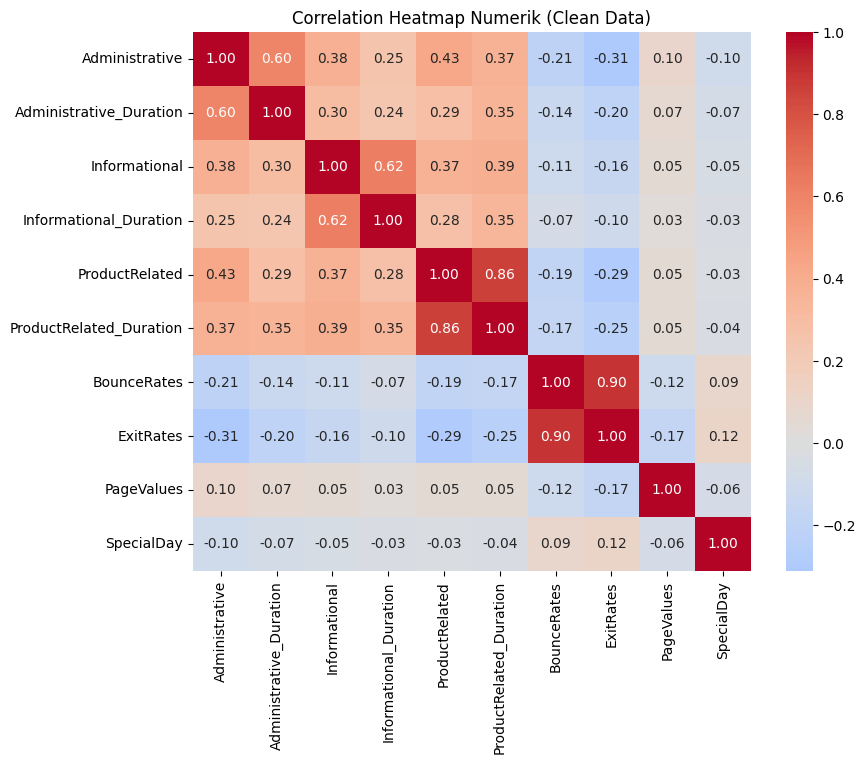

In [34]:
plt.figure(figsize=(9,7))
sns.heatmap(df_clean[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap Numerik (Clean Data)')
plt.show()

#### Data Preprocessing

In [35]:
# Split features & target
X = df_clean.drop(columns=['Revenue'])
y = df_clean['Revenue']

In [36]:
# Train-test split (stratify)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [37]:
# Encoding dilakukan setelah split
# Fit dummy variables dari X_train, lalu sesuaikan kolom X_test agar sama dengan kolom X_train.
cat_cols = ['Month', 'VisitorType']
X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True, dtype=int)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True, dtype=int)

# Samakan kolom X_test dengan X_train:
# kategori yang ada di X_train tapi tidak muncul di X_test: diisi 0
# kategori yang muncul di X_test tapi tidak pernah dilihat X_train: otomatis dibuang
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

X_train.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
7556,8,203.6,1,0.0,42,1052.400000,0.0,0.004545,37.357258,0.0,...,0,0,0,0,0,1,0,0,0,1
11924,0,0.0,0,0.0,30,901.288889,0.0,0.007333,34.148420,0.0,...,0,0,0,0,0,0,0,0,0,0
3306,0,0.0,0,0.0,13,421.166667,0.0,0.028205,0.000000,0.8,...,0,0,0,0,1,0,0,0,0,1
207,2,40.0,0,0.0,5,558.500000,0.0,0.028571,0.000000,0.0,...,0,0,0,1,0,0,0,0,0,0
4460,0,0.0,0,0.0,16,1599.266667,0.0,0.013333,0.000000,0.0,...,0,0,0,0,1,0,0,0,0,1


#### Outlier Handling

In [38]:
# Handle Outlier di fitur Duration dilakukan setelah split
import numpy as np

duration_cols = ['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration']

for col in duration_cols:
    p99 = X_train[col].quantile(0.99)
    n_train = (X_train[col] > p99).sum()
    n_test = (X_test[col] > p99).sum()
    print(f"{col}: p99 (train)={p99:.1f} | outlier di-cap -> train: {n_train}, test: {n_test}")

    X_train[col] = np.where(X_train[col] > p99, p99, X_train[col])
    X_test[col] = np.where(X_test[col] > p99, p99, X_test[col])

Administrative_Duration: p99 (train)=845.5 | outlier di-cap -> train: 98, test: 23
Informational_Duration: p99 (train)=746.8 | outlier di-cap -> train: 98, test: 18
ProductRelated_Duration: p99 (train)=8690.3 | outlier di-cap -> train: 98, test: 27


Penanganan outlier pada fitur durasi (Administrative_Duration, Informational_Duration, ProductRelated_Duration) dilakukan dengan metode capping pada persentil ke-99, di mana ambang batas (p99) dihitung khusus dari X_train agar tidak terjadi kebocoran informasi dari data test. Ambang batas tersebut kemudian diterapkan untuk meng-cap nilai ekstrem baik pada X_train maupun X_test.

In [39]:
# Statistik X_train setelah outlier handling
X_train[duration_cols].describe()

,Administrative_Duration,Informational_Duration,ProductRelated_Duration
count,9764.000000,9764.000000,9764.000000
mean,77.453950,30.778694,1165.143514
std,143.453739,107.296450,1546.070569
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,193.466667
50%,9.000000,0.000000,617.000000
75%,94.725000,0.000000,1483.650000
max,845.532857,746.845000,8690.320114


#### Modeling

In [40]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [41]:
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [42]:
# Random Forest
from sklearn.model_selection import RandomizedSearchCV
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

rf_pipe = Pipeline([
    ('smote', SMOTE(sampling_strategy=0.5, random_state=42)), # smote (oversampling kelas minoritas)
    ('clf', RandomForestClassifier(random_state=42, n_jobs=1))
])

rf_params = {
    'clf__n_estimators': [400, 600, 900],
    'clf__max_depth': [8, 12, 16],
    'clf__min_samples_leaf': [2, 4, 6],
    'clf__min_samples_split': [2, 5, 10],
    'clf__max_features': ['sqrt', 0.5]
}

rf_search = RandomizedSearchCV(
    rf_pipe,
    rf_params,
    n_iter=40,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=2
)
rf_search.fit(X_train, y_train)
rf = rf_search.best_estimator_
print("Best RF params:", rf_search.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best RF params: {'clf__n_estimators': 400, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 4, 'clf__max_features': 0.5, 'clf__max_depth': 8}


In [43]:
# XGBoost
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

xgb_pipe = Pipeline([
    ('smote', SMOTE(sampling_strategy=0.5, random_state=42)),
    ('clf', XGBClassifier(eval_metric='logloss', random_state=42))
])

xgb_params = {
    'clf__n_estimators': [300, 500, 800],
    'clf__max_depth': [3, 4, 5, 6],
    'clf__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'clf__subsample': [0.7, 0.8, 1.0],
    'clf__colsample_bytree': [0.6, 0.8, 1.0],
    'clf__min_child_weight': [1, 3, 5],
    'clf__gamma': [0, 0.1, 0.3],
    'clf__reg_alpha': [0, 0.1, 0.5],
    'clf__reg_lambda': [1, 2, 5]
}

xgb_search = RandomizedSearchCV(
    xgb_pipe,
    xgb_params,
    n_iter=60,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    random_state=42
)
xgb_search.fit(X_train, y_train)
xgb = xgb_search.best_estimator_
print("Best XGB params:", xgb_search.best_params_)

Best XGB params: {'clf__subsample': 1.0, 'clf__reg_lambda': 1, 'clf__reg_alpha': 0, 'clf__n_estimators': 300, 'clf__min_child_weight': 3, 'clf__max_depth': 5, 'clf__learning_rate': 0.01, 'clf__gamma': 0, 'clf__colsample_bytree': 1.0}


In [44]:
print("RF best CV F1-Score:", rf_search.best_score_)
print("XGB best CV F1-Score:", xgb_search.best_score_)

RF best CV F1-Score: 0.687783186218884
XGB best CV F1-Score: 0.6866157890276197


In [45]:
# Prediksi
proba_rf = rf.predict_proba(X_test)[:, 1]
proba_xgb = xgb.predict_proba(X_test)[:, 1]

y_pred_rf = rf.predict(X_test)
y_pred_xgb = xgb.predict(X_test)

#### Evaluasi

In [46]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

print("Random Forest")
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, proba_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest
Accuracy : 0.8972
Precision: 0.6479
Recall   : 0.7513
F1-Score : 0.6958
ROC-AUC  : 0.9331

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.92      0.94      2059
           1       0.65      0.75      0.70       382

    accuracy                           0.90      2441
   macro avg       0.80      0.84      0.82      2441
weighted avg       0.90      0.90      0.90      2441



In [47]:
print("XGBoost")
print(f"Accuracy : {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, proba_xgb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost
Accuracy : 0.8935
Precision: 0.6356
Recall   : 0.7487
F1-Score : 0.6875
ROC-AUC  : 0.9334

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.92      0.94      2059
           1       0.64      0.75      0.69       382

    accuracy                           0.89      2441
   macro avg       0.79      0.83      0.81      2441
weighted avg       0.90      0.89      0.90      2441



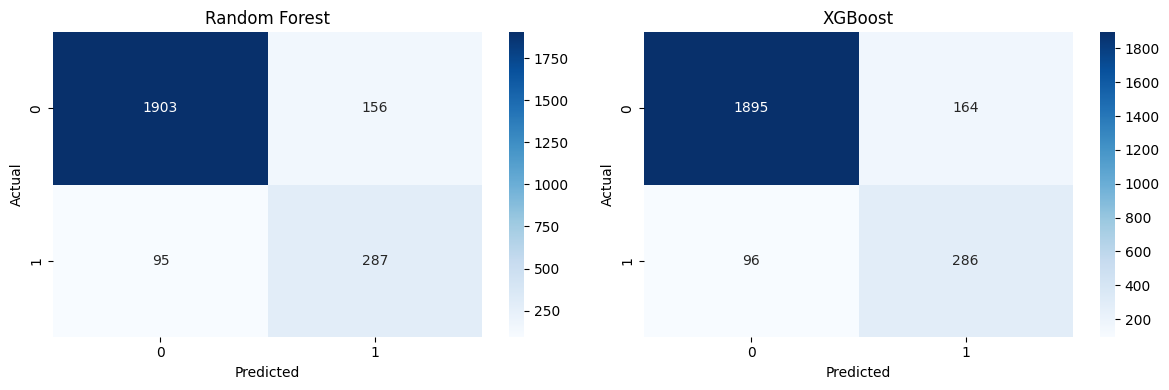

In [48]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
preds = [("Random Forest", y_pred_rf), ("XGBoost", y_pred_xgb)]
for ax, (name, pred) in zip(axes, preds):
    sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

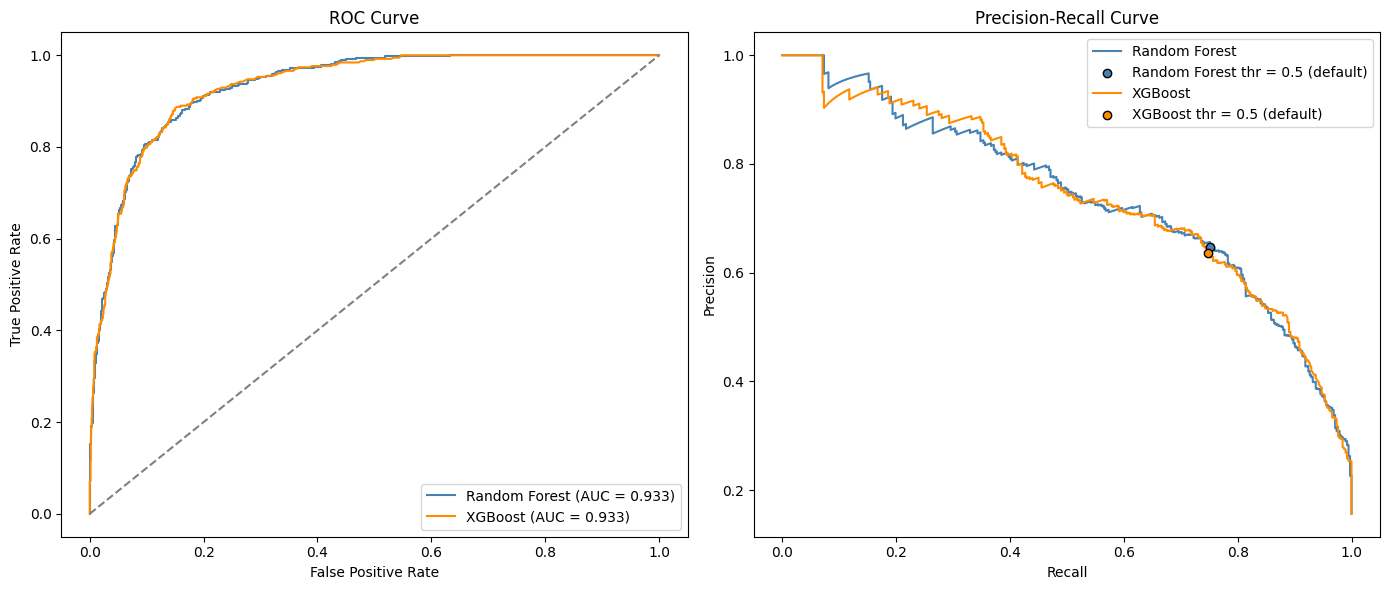

In [49]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curve
for proba, name, color in [(proba_rf, "Random Forest", "steelblue"), (proba_xgb, "XGBoost", "darkorange")]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})", color=color)

axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

# Precision-Recall Curve
for proba, y_pred_default, name, color in [
    (proba_rf, y_pred_rf, "Random Forest", "steelblue"),
    (proba_xgb, y_pred_xgb, "XGBoost", "darkorange")
]:
    prec, rec, thr = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, label=name, color=color)

    prec_at_thr = precision_score(y_test, y_pred_default)
    rec_at_thr = recall_score(y_test, y_pred_default)
    axes[1].scatter(rec_at_thr, prec_at_thr, color=color, edgecolor='black', zorder=5,
                     label=f"{name} thr = 0.5 (default)")

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

Feature Importance

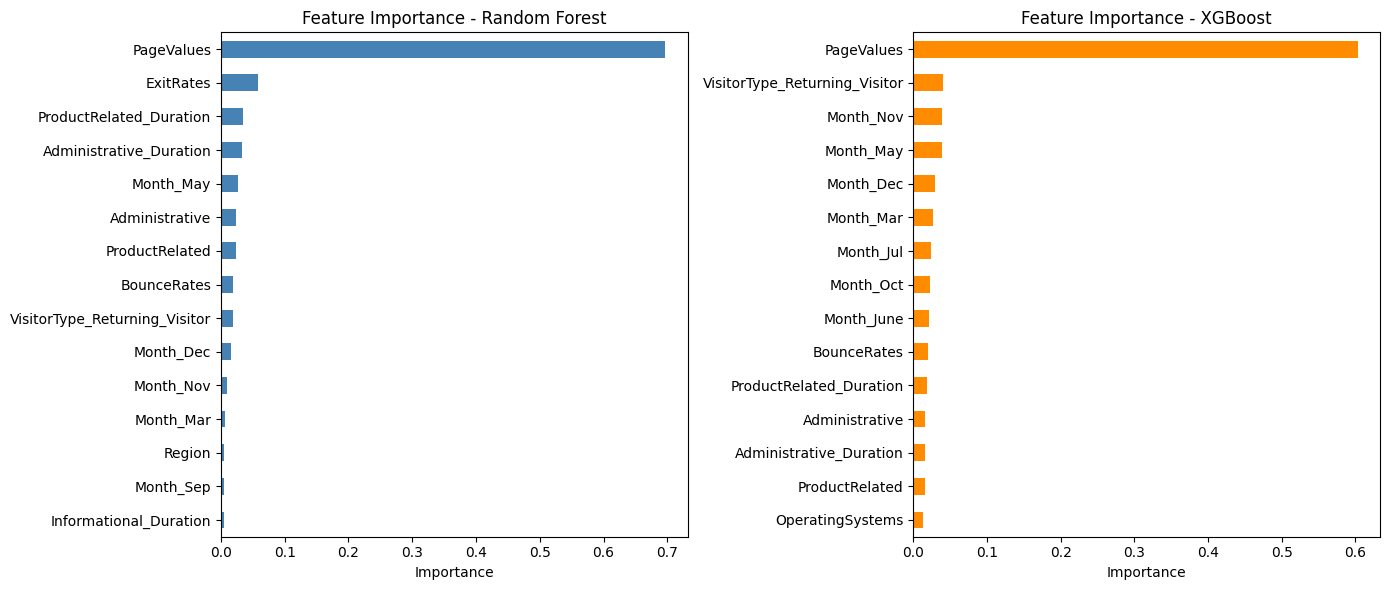

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

# Ambil feature importance dari masing-masing model
rf_importance = pd.Series(rf.named_steps['clf'].feature_importances_, index=X_train.columns)
xgb_importance = pd.Series(xgb.named_steps['clf'].feature_importances_, index=X_train.columns)

# Urutkan dari yang paling berpengaruh
rf_importance = rf_importance.sort_values(ascending=False)
xgb_importance = xgb_importance.sort_values(ascending=False)

# Plot berdampingan
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

rf_importance.head(15).sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Feature Importance - Random Forest')
axes[0].set_xlabel('Importance')

xgb_importance.head(15).sort_values().plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Feature Importance - XGBoost')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

#### Kesimpulan

Dari total 12.205 data pengunjung yang dianalisis setelah proses *cleaning*, hanya 15,6% (1.908 pengunjung) yang benar-benar melakukan pembelian, menunjukkan adanya ketidakseimbangan kelas (*class imbalance*) yang cukup signifikan pada data.

Hasil eksplorasi data mengindikasikan bahwa PageValues memiliki korelasi positif terkuat terhadap Revenue (0,49), yang berarti pengunjung yang lebih sering mengakses halaman bernilai ekonomis tinggi cenderung memiliki peluang lebih besar untuk melakukan pembelian. Sebaliknya, ExitRates menunjukkan korelasi negatif (-0,20), yang mengindikasikan bahwa semakin tinggi kemungkinan visitor keluar dari suatu halaman, semakin kecil peluang mereka melakukan pembelian. Selain itu, ditemukan bahwa New Visitor memiliki conversion rate lebih tinggi (24,9%) dibandingkan Returning Visitor (13,9%), serta terdapat variasi conversion rate yang cukup besar antar bulan, dengan November mencatat tingkat konversi tertinggi (25,35%) dan Februari terendah (1,63%).

Untuk memprediksi target Revenue, dilakukan pemodelan klasifikasi menggunakan algoritma Random Forest dan XGBoost, dengan penanganan class imbalance melalui teknik SMOTE serta optimasi hyperparameter menggunakan RandomizedSearchCV. Berdasarkan hasil evaluasi pada data uji, kedua model menghasilkan performa yang relatif setara, yaitu F1-score sebesar 0,6958 untuk Random Forest dan 0,6875 untuk XGBoost, dengan ROC-AUC masing-masing sebesar 0,9331 dan 0,9334. Nilai akurasi keseluruhan mencapai sekitar 89-90%, sedangkan pada kelas minoritas pembeli diperoleh precision sekitar 0,64–0,65 dan recall sekitar 0,75.

Hasil analisis feature importance dari kedua model secara konsisten menunjukkan bahwa PageValues merupakan fitur paling berpengaruh dalam memprediksi keputusan pembelian dibandingkan fitur lainnya seperti ExitRates, Month_Nov, dan durasi kunjungan pada halaman produk.